# 5T OTA : Gain as spec
Get maximum bandwidth for given Gain

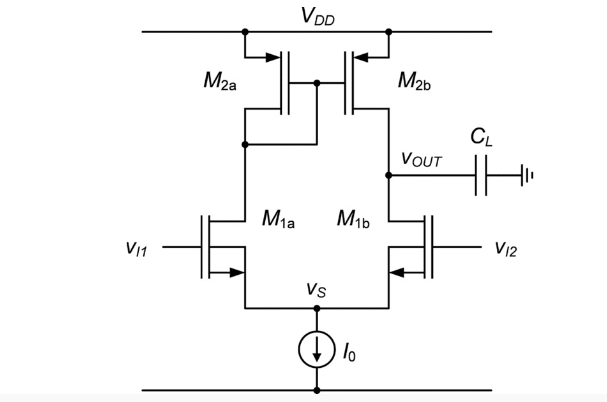
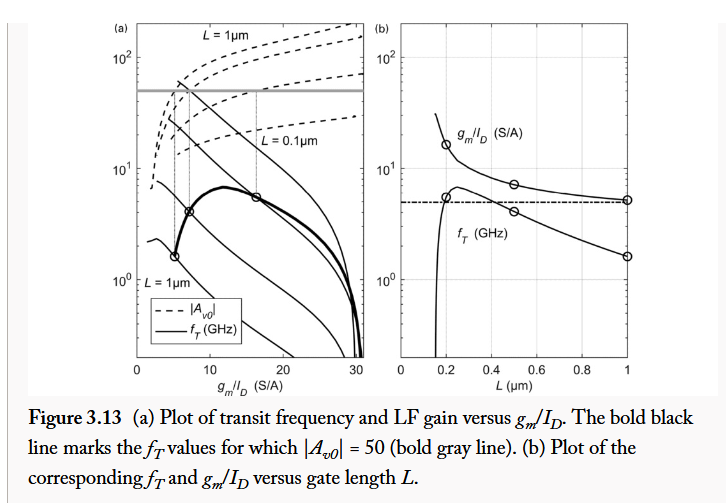  
Sizing at constant gain, for 1 max frequency, 2 min current for max frequency*0.8

## Import libs

In [61]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
import sys; sys.path.append('../..')
import adri
pmos4 = lk('../../lookup_table/035/pmos4.mat')
nmos4 = lk('../../lookup_table/035/nmos4.mat')

## Specification / Parameter

In [62]:
#Specification
AV_spec = 1000
#Plot of GM_ID and FT for each L where AV0 == AV_spec, On veut les valeur gmID et FT pour lesquel AV0 = AVREF
Npoint = 30
gmid_test = np.linspace(1,26,Npoint)
L_test = np.linspace(.35,10.0,Npoint)

## Plot of gm/if and FT versus L for AV0 == AVspec
Use to find L and gm/id for maximum bandwidth

Pour un gain de  1000
La FT_max est de GHz 0.003863269100802101
Pour la FT maximum, il faut L = :  9.667241379310344
Pour la FT maximum, il faut gmid = :  19.874889441691746


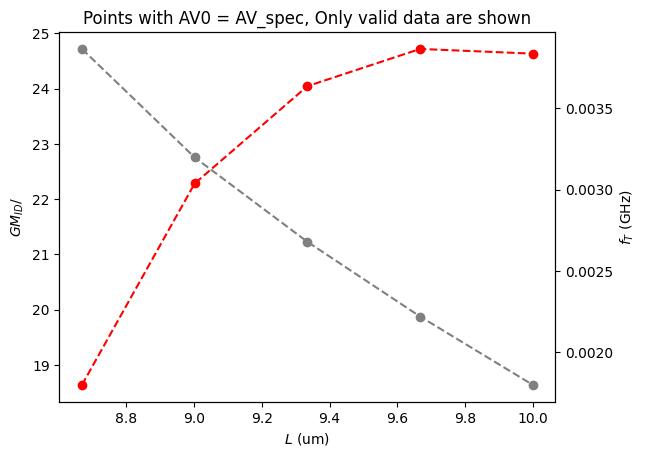

In [63]:
l_for_ftmax, gmid_for_ftmax, ft_max = adri.get_L_GMID_ota_5T_for_AV0(nmos4, pmos4, gmid_test, L_test, AV_spec)
print("Pour un gain de ", AV_spec)
print("La FT_max est de GHz", ft_max)
print("Pour la FT maximum, il faut L = : ", l_for_ftmax)
print("Pour la FT maximum, il faut gmid = : ", gmid_for_ftmax)

## Get design parameter
Set L12 and gm_id given the optimal point or use what you want

In [65]:
#Keep same FU or use a lower one
FU = ft_max * 1e9
FU = 100e3

spec = {'fu' : FU,
        'cload' : 10e-12,
        'vdd' : 2.7,
        'vic' : 1.35
        }
param = {
        'l_mos' : l_for_ftmax,
         'gm_id1' : gmid_for_ftmax,
         'gm_id2' : gmid_for_ftmax
         }
m1,m2, perf = adri.ota_5T_L_gmid(nmos4, pmos4, spec, param)
adri.print_design_summary(spec,perf,m1,m2)